# Step 1: Import Required Libraries

In this step, we import all the libraries required for data manipulation,
visualization, preprocessing, model building, evaluation, and hyperparameter tuning.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time

# ============================================================
# Ignore Warning Messages
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Display Settings
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


# Step 2: Load the Dataset

The Email Spam dataset is loaded into a Pandas DataFrame.

The dataset contains numerical features extracted from emails and a target column
indicating whether an email is spam or not.

In [6]:
df = pd.read_csv("/home/mtech1/spambase_csv.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Step 3: Dataset Overview

Before building any machine learning model, it is important to understand
the structure of the dataset.

The following information is obtained:

- Shape
- Columns
- Data Types
- First Five Records
- Statistical Summary

In [9]:

print("="*80)
print("Dataset Shape")
print("="*80)

print(df.shape)

print("\n")
print("="*80)
print("Column Names")
print("="*80)

print(df.columns.tolist())

print("\n")
print("="*80)
print("First Five Records")
print("="*80)

display(df.head())


print("\n")
print("="*80)
print("Dataset Information")
print("="*80)

df.info()


print("\n")
print("="*80)
print("Statistical Summary")
print("="*80)

display(df.describe())

Dataset Shape
(4601, 58)


Column Names
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1




Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report      

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,0.059824,0.541702,0.093930,0.058626,0.049205,0.248848,0.142586,0.184745,1.662100,0.085577,0.809761,0.121202,0.101645,0.094269,0.549504,0.265384,0.767305,0.124845,0.098915,0.102852,0.064753,0.047048,0.097229,0.047835,0.105412,0.097477,0.136953,0.013201,0.078629,0.064834,0.043667,0.132339,0.046099,0.079196,0.301224,0.179824,0.005444,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,0.201545,0.861698,0.301036,0.335184,0.258843,0.825792,0.444055,0.531122,1.775481,0.509767,1.200810,1.025756,0.350286,0.442636,1.671349,0.886955,3.367292,0.538576,0.593327,0.456682,0.403393,0.328559,0.555907,0.329445,0.532260,0.402623,0.423451,0.220651,0.434672,0.349916,0.361205,0.766819,0.223812,0.621976,1.011687,0.911119,0.076274,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.310000,0.000000,0.220000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

# Step 4: Data Quality Check

Data quality is verified by checking:

- Missing values
- Duplicate records

A clean dataset helps improve model performance.

In [10]:

print("="*80)
print("Missing Values")
print("="*80)

display(df.isnull().sum())

print("\n")
print("="*80)
print("Duplicate Rows")
print("="*80)

print(df.duplicated().sum())

Missing Values


word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre



Duplicate Rows
391


In [14]:

duplicate_count = df.duplicated().sum()
print("Duplicate Rows Before Removal :", duplicate_count)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates :", df.shape)

Duplicate Rows Before Removal : 0
Dataset Shape After Removing Duplicates : (4210, 58)


In [16]:
print("="*70)
print("Missing Values After Cleaning")
print("="*70)

print(df.isnull().sum())

Missing Values After Cleaning
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_

### Observation

- The SpamBase dataset contains no missing values.
- Duplicate rows (if present) were removed.
- The cleaned dataset will be used for further analysis.

# Step 3 : Feature Normalization

Machine Learning algorithms such as KNN use distance calculations.

Features with larger numerical values dominate the distance calculation.

Therefore, all input features are normalized before training.

In [18]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Normalization Completed.")

Normalization Completed.


In [22]:
print(X_scaled.head(2))

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0        0.000000           0.044818       0.125490           0.0   
1        0.046256           0.019608       0.098039           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0          0.032        0.000000          0.000000            0.000000   
1          0.014        0.047619          0.028886            0.006301   

   word_freq_order  word_freq_mail  word_freq_receive  word_freq_will  \
0              0.0        0.000000            0.00000        0.066184   
1              0.0        0.051705            0.08046        0.081696   

   word_freq_people  word_freq_report  word_freq_addresses  word_freq_free  \
0          0.000000             0.000             0.000000           0.016   
1          0.117117             0.021             0.031746           0.007   

   word_freq_business  word_freq_email  word_freq_you  word_freq_credit  \
0            0.000000         0.141914 

### Observation

After normalization every feature value lies between 0 and 1.

Normalization is particularly important for KNN because it computes distances
between data points.

# 4.1 Class Distribution

The class distribution shows whether the dataset is balanced or imbalanced.

Class Labels:

- 0 → Non-Spam
- 1 → Spam

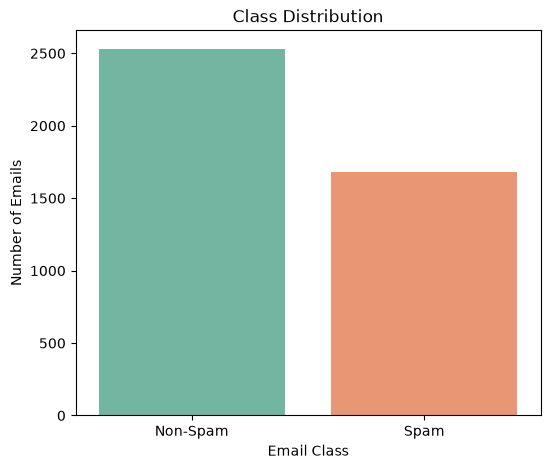

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="class",
    palette="Set2"
)

plt.title("Class Distribution")

plt.xlabel("Email Class")

plt.ylabel("Number of Emails")

plt.xticks([0,1],["Non-Spam","Spam"])

plt.show()

### Observation

- The plot shows the number of spam and non-spam emails.
- The given dataset is imbalanced it has more number of Non-Spam emails than the Spam

# 4.2 Missing Value Heatmap

This heatmap helps visualize missing values across all features.

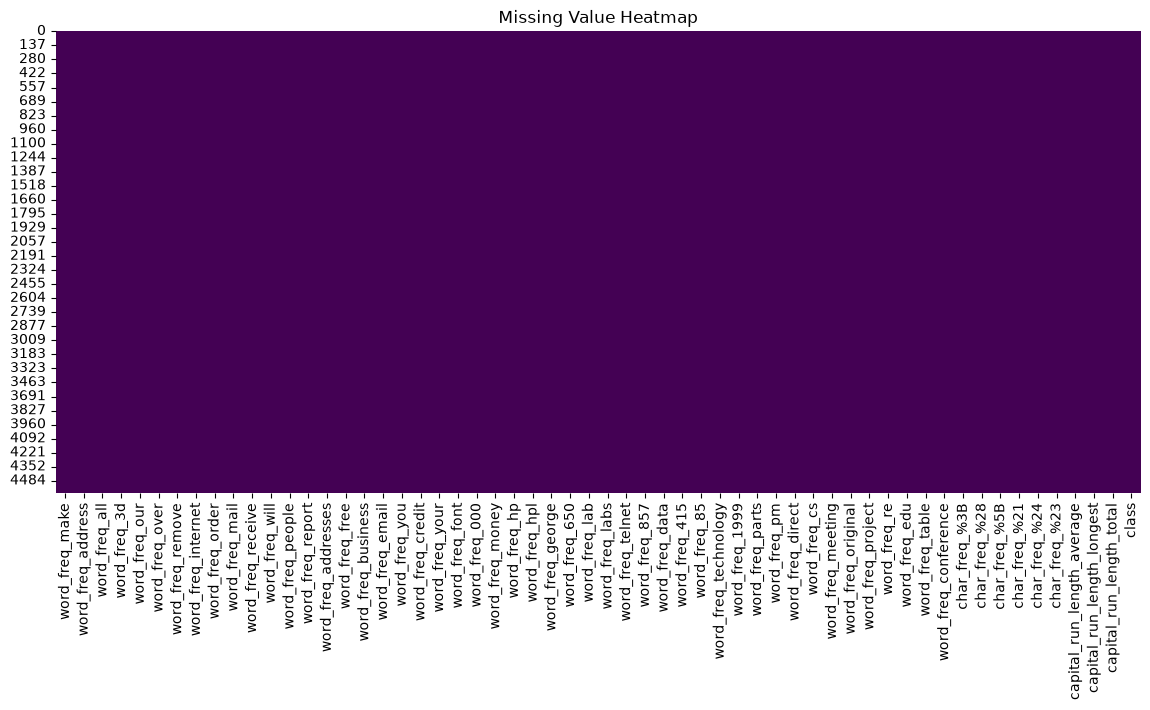

In [24]:
plt.figure(figsize=(14,6))

sns.heatmap(

    df.isnull(),

    cbar=False,

    cmap="viridis"

)

plt.title("Missing Value Heatmap")

plt.show()

### Observation

No colored gaps indicate that the SpamBase dataset does not contain missing values.


# 4.3 Missing Value Count

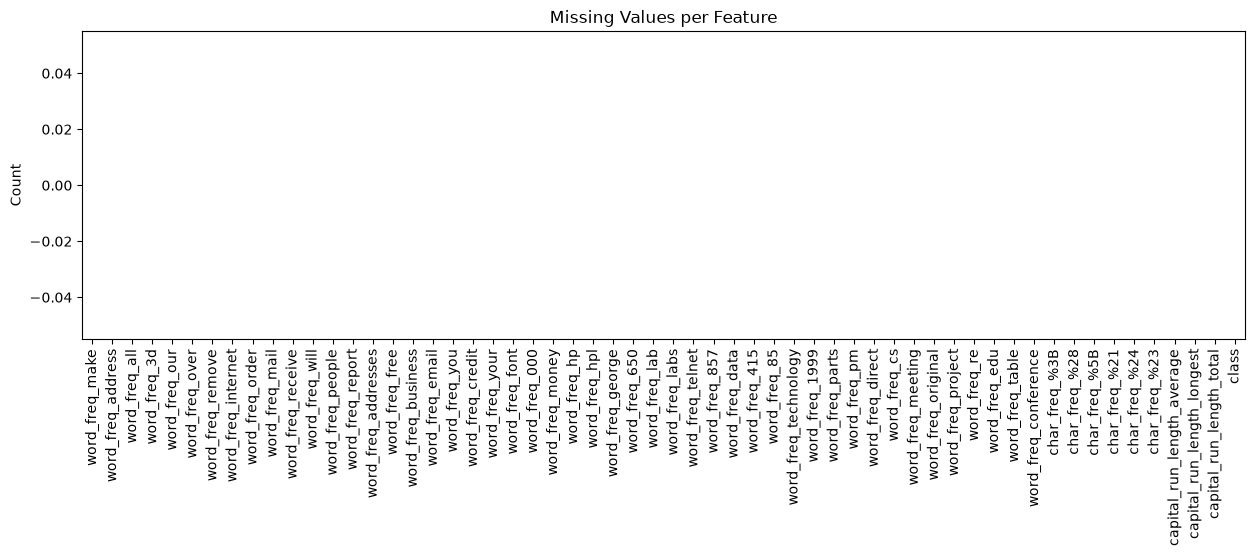

In [25]:
missing = df.isnull().sum()

plt.figure(figsize=(15,4))

missing.plot(kind="bar")

plt.title("Missing Values per Feature")

plt.ylabel("Count")

plt.show()

### Observation

Every feature contains zero missing values.

# 4.4 Correlation Heatmap

The heatmap shows the correlation between numerical features.

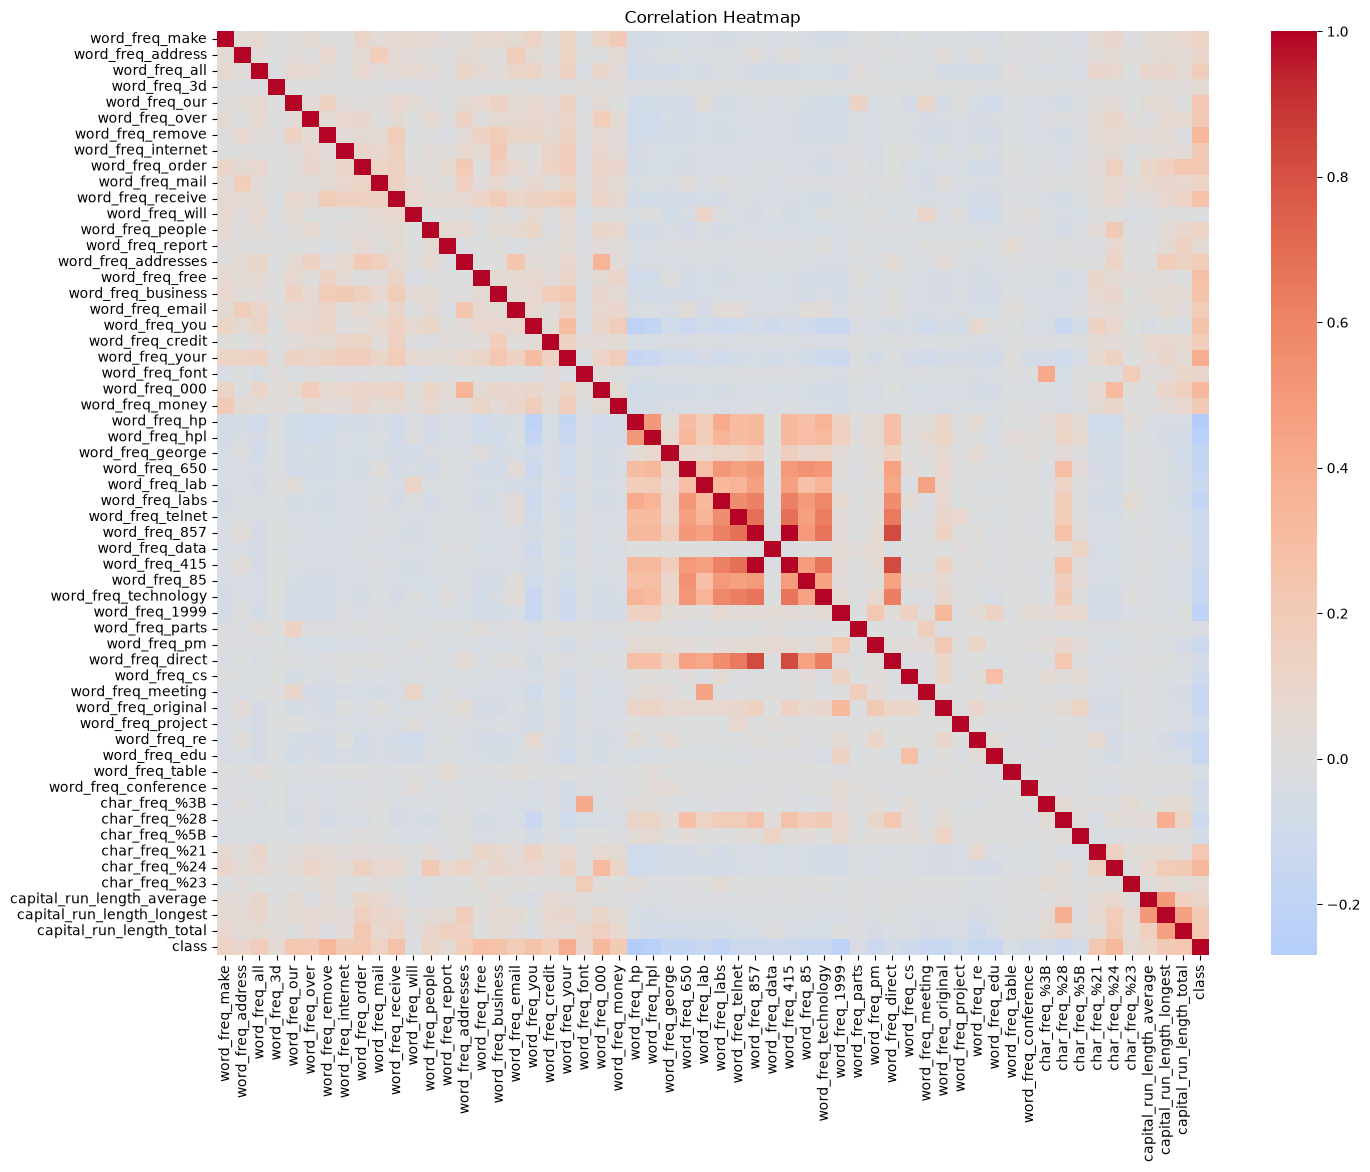

In [62]:
plt.figure(figsize=(16,12))

sns.heatmap(

    df.corr(),


    cmap="coolwarm",

    center=0

)

plt.title("Correlation Heatmap")

plt.show()

### Observation

Features with darker colors are more strongly correlated.

Highly correlated features may contain redundant information.

# 4.5 Cluster Map

The cluster map groups similar features together based on correlation.

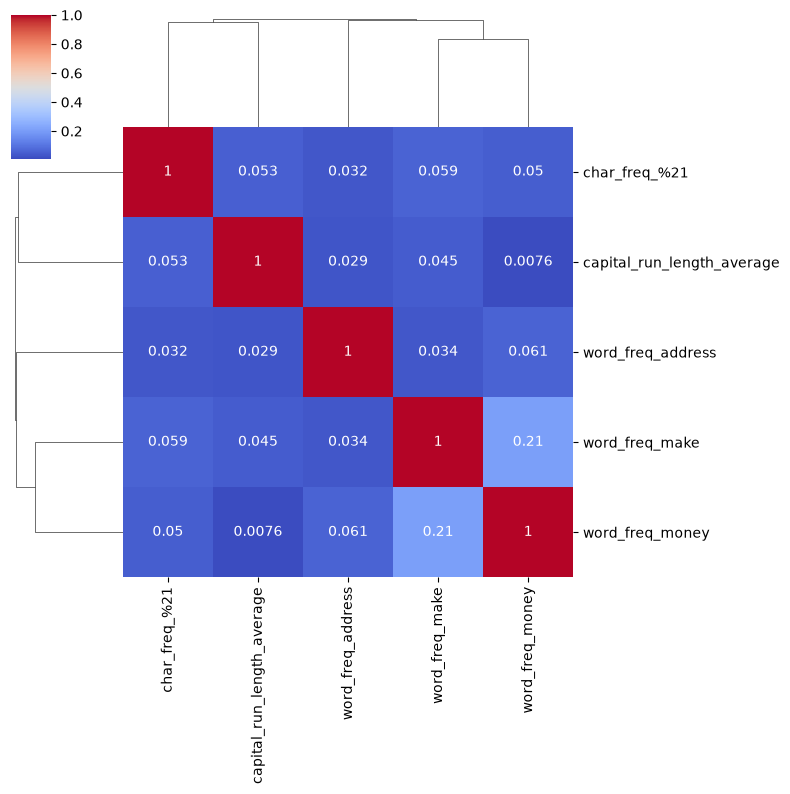

In [38]:
important_features = [

    "word_freq_make",

    "word_freq_address",

    "word_freq_money",

    "char_freq_%21",

    "capital_run_length_average"

]
sns.clustermap(
    df[important_features].corr(),
    cmap="coolwarm",
    annot=True,
    figsize=(8,8)
)

plt.show()

### Observation

Features with similar behaviour are grouped into the same cluster.

# 4.6 Histograms of Important Features

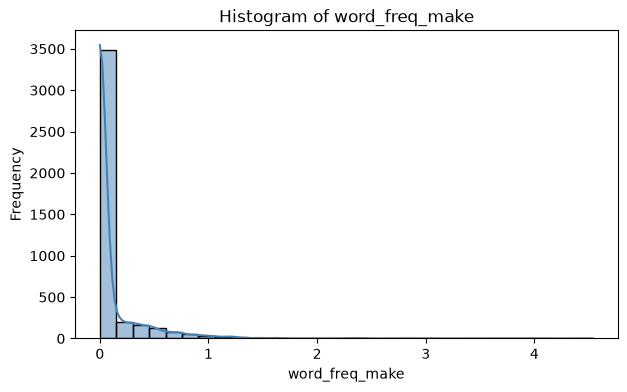

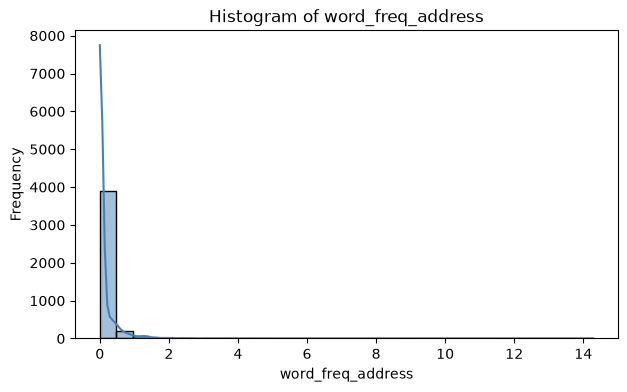

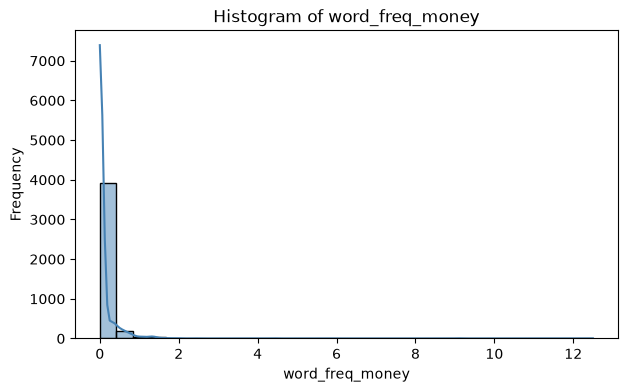

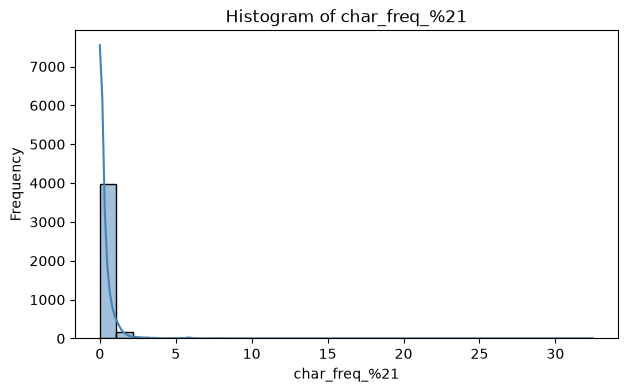

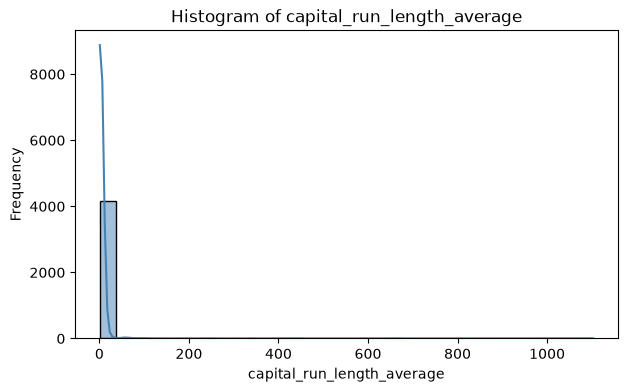

In [33]:


for feature in important_features:

    plt.figure(figsize=(7,4))

    sns.histplot(

        df[feature],

        kde=True,

        bins=30,

        color="steelblue"

    )

    plt.title(f"Histogram of {feature}")

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.show()

### Observation

The histogram helps identify skewness, spread and possible outliers in each feature.

# 4.7 Kernel Density Estimation (KDE)

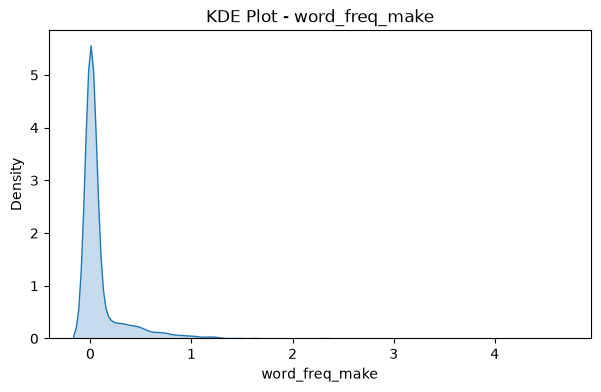

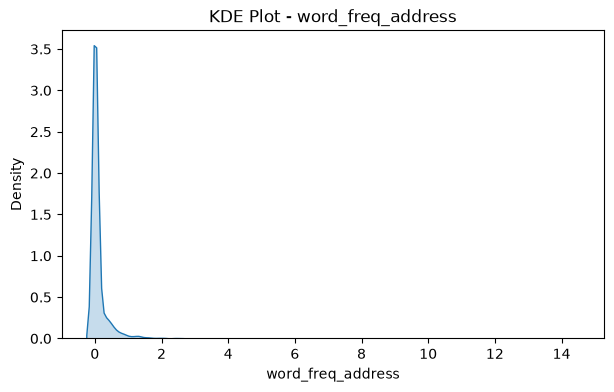

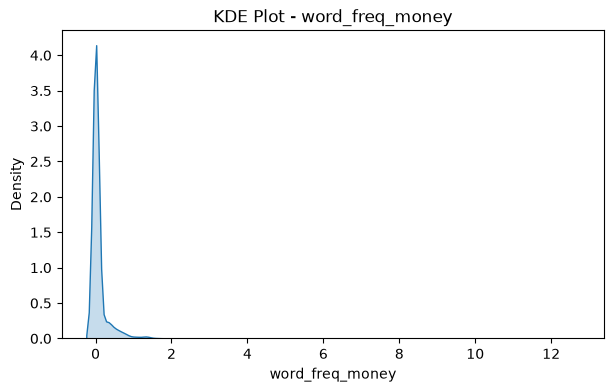

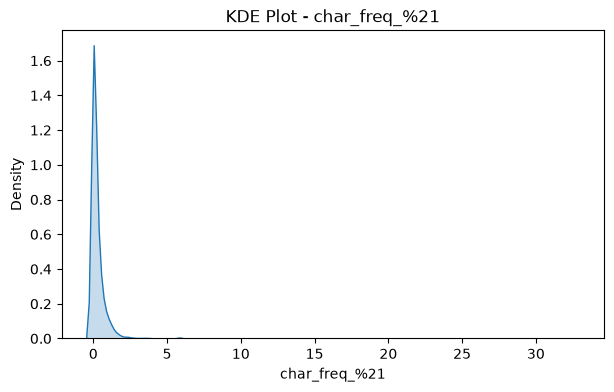

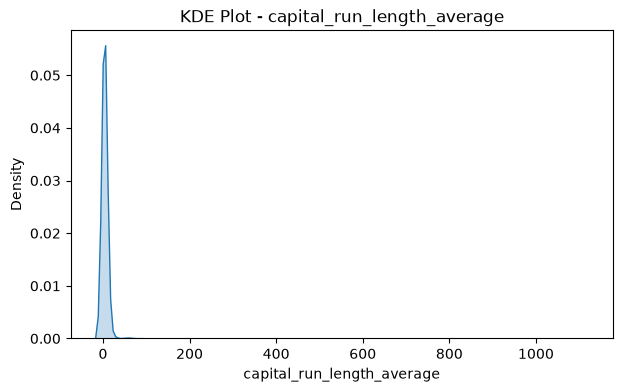

In [42]:
for feature in important_features:

    plt.figure(figsize=(7,4))

    sns.kdeplot(

        df[feature],

        fill=True

    )

    plt.title(f"KDE Plot - {feature}")

    plt.show()

### Observation

The KDE curve provides a smooth estimate of the probability density.

# 4.8 Box Plots

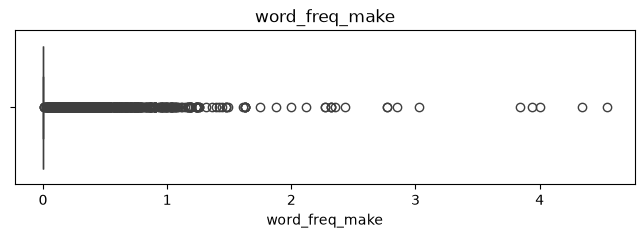

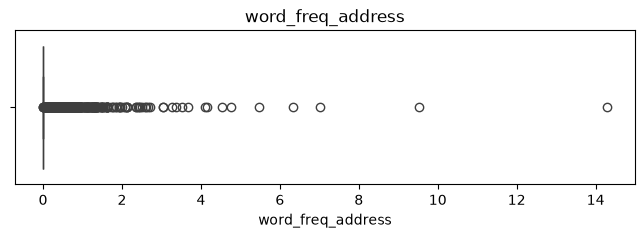

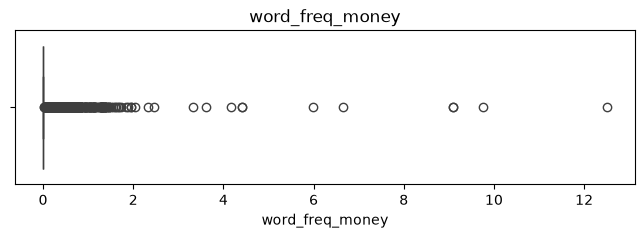

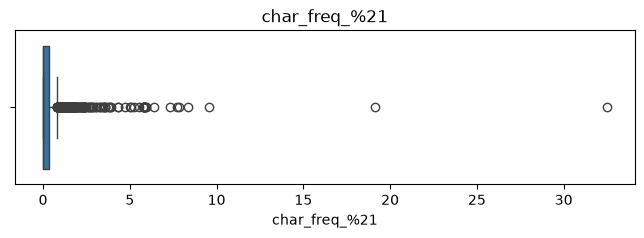

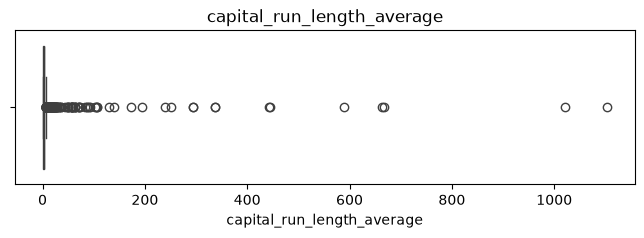

In [46]:
for feature in important_features:

    plt.figure(figsize=(8,2))

    sns.boxplot(

        x=df[feature]

    )

    plt.title(feature)

    plt.show()

### Observation

Outliers appear as points beyond the whiskers.

# 4.9 Violin Plots

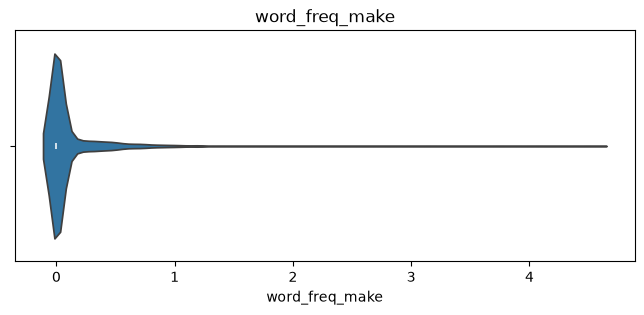

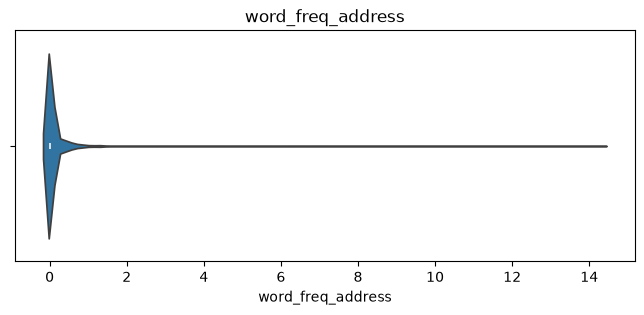

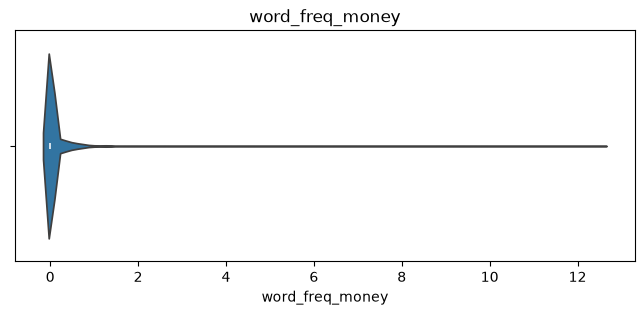

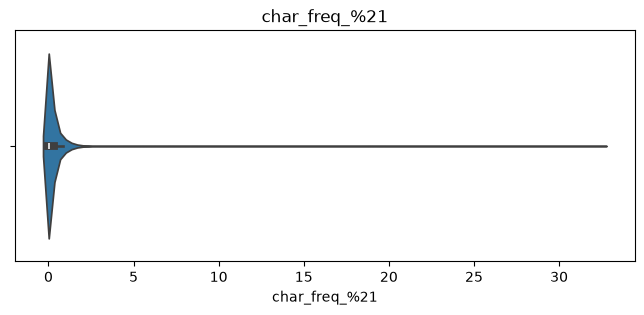

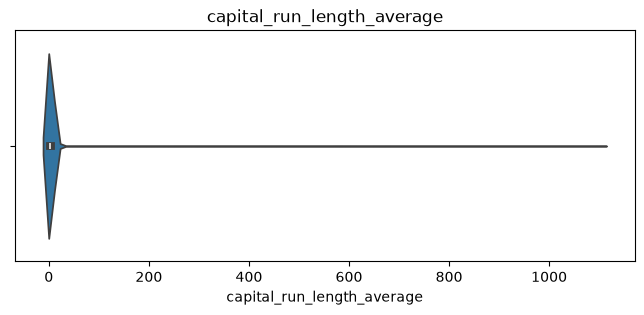

In [47]:
for feature in important_features:

    plt.figure(figsize=(8,3))

    sns.violinplot(

        x=df[feature]

    )

    plt.title(feature)

    plt.show()

### Observation

Violin plots combine box plots with probability density information.

# 4.10 Scatter Plot

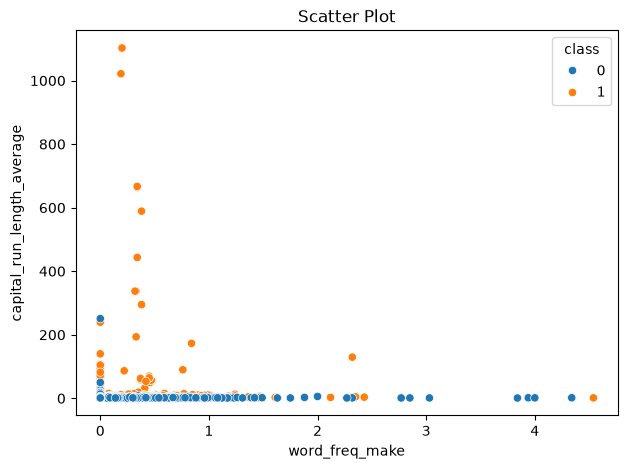

In [48]:
plt.figure(figsize=(7,5))

sns.scatterplot(

    data=df,

    x="word_freq_make",

    y="capital_run_length_average",

    hue="class"

)

plt.title("Scatter Plot")

plt.show()

### Observation

The scatter plot helps visualize the relationship between two features and the class labels.

# 4.11 Pair Plot

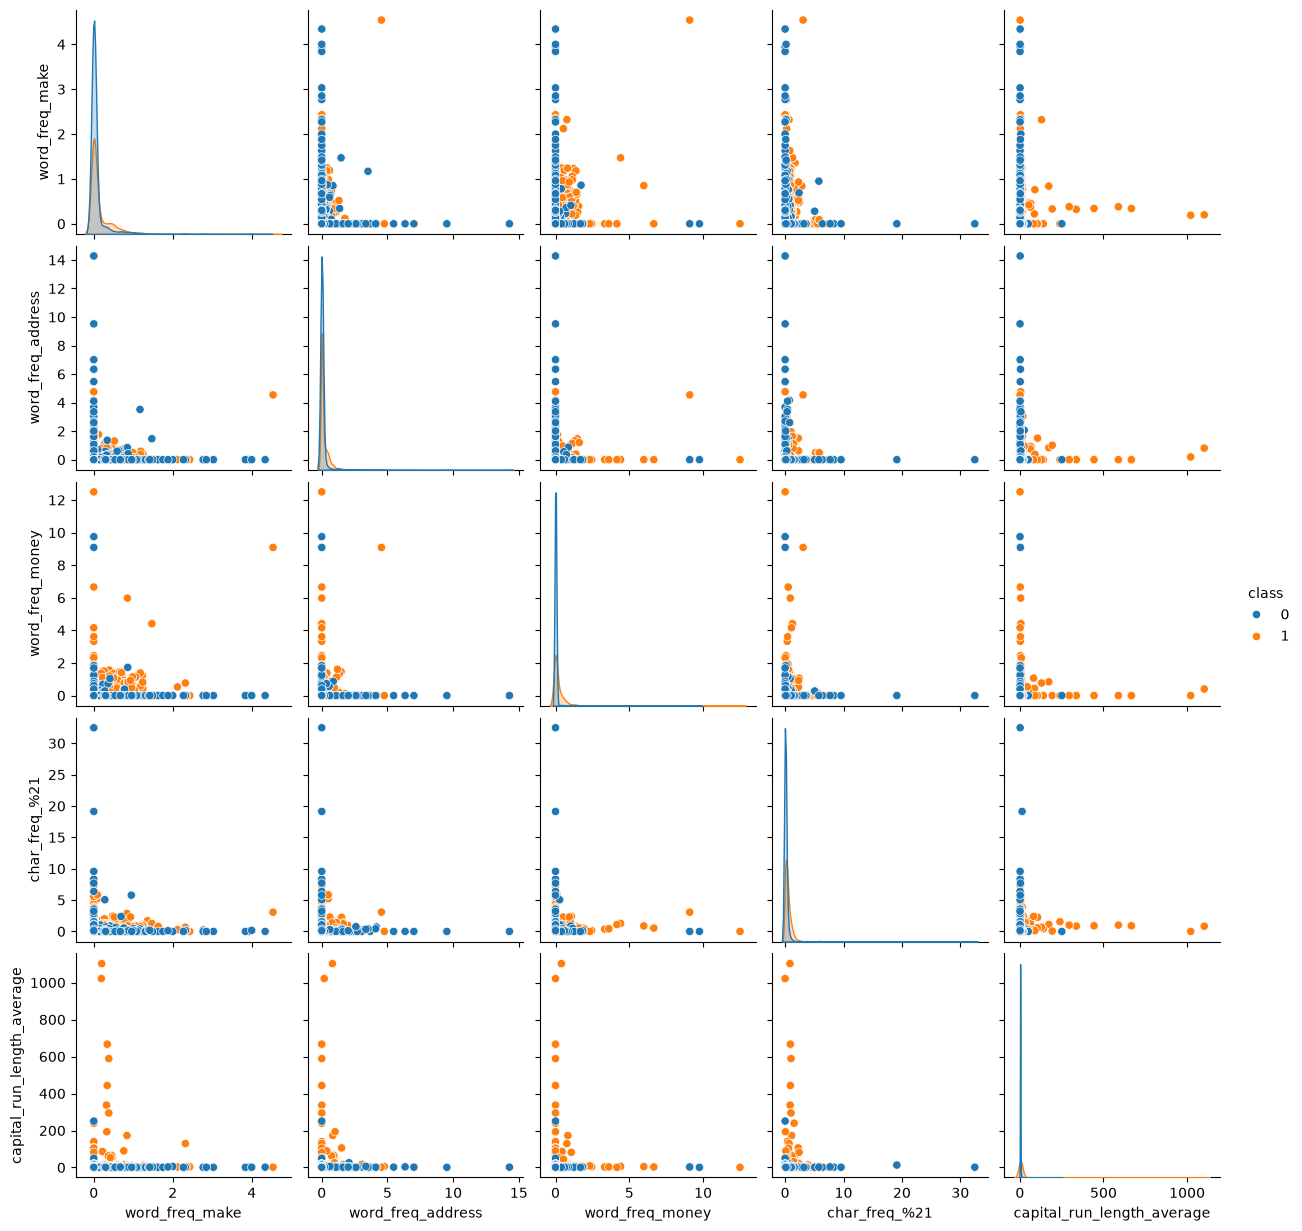

In [49]:
pair_df = df[important_features + ["class"]]

sns.pairplot(

    pair_df,

    hue="class",

    diag_kind="kde"

)

plt.show()

### Observation

The pair plot visualizes pairwise relationships among the selected features.

# 4.12 Grouped Box Plot

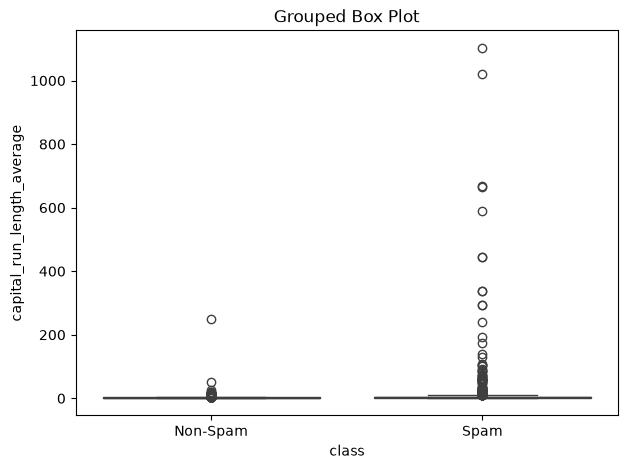

In [50]:
plt.figure(figsize=(7,5))

sns.boxplot(

    data=df,

    x="class",

    y="capital_run_length_average"

)

plt.xticks([0,1],["Non-Spam","Spam"])

plt.title("Grouped Box Plot")

plt.show()

### Observation

The grouped box plot compares the distribution of a feature across spam and non-spam emails.

# 4.13 Quantile-Quantile Plot

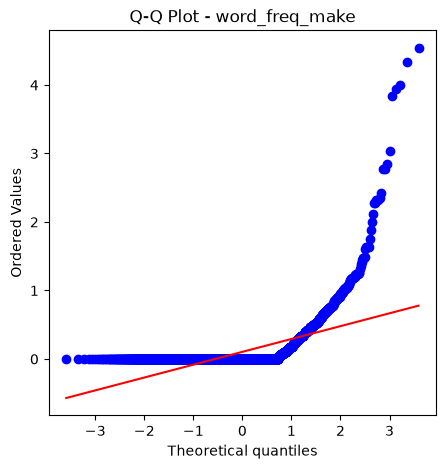

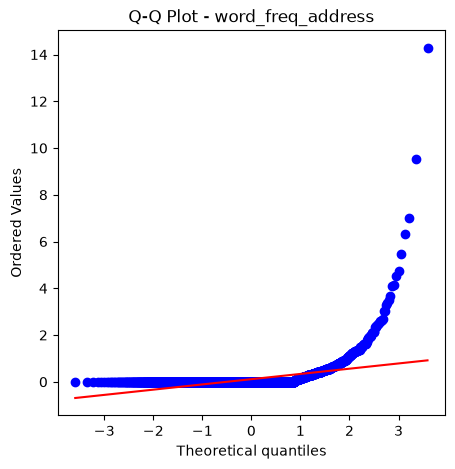

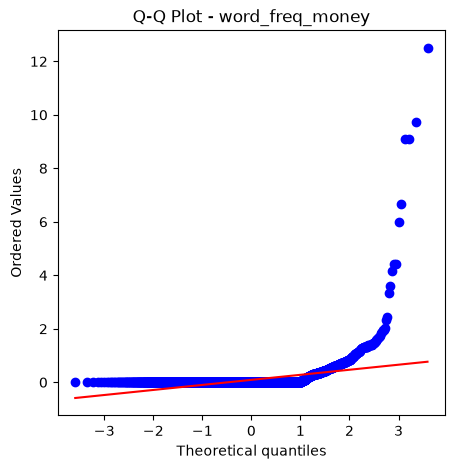

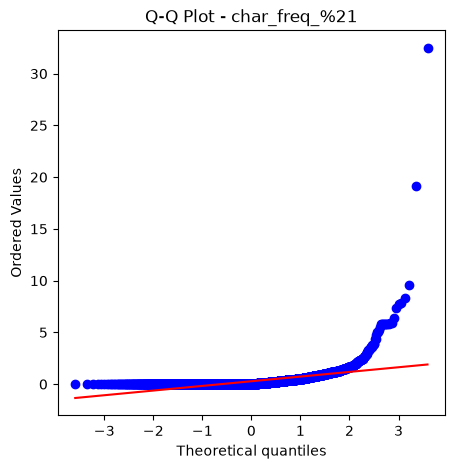

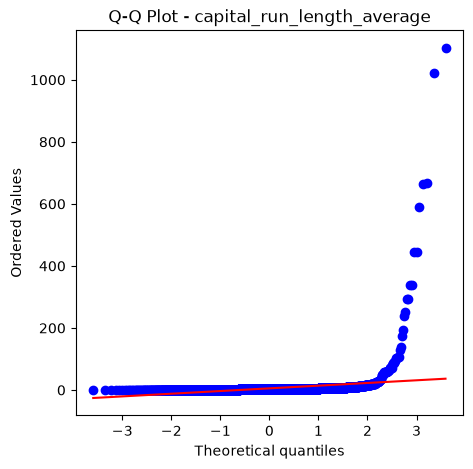

In [51]:
from scipy import stats

for feature in important_features:

    plt.figure(figsize=(5,5))

    stats.probplot(

        df[feature],

        dist="norm",

        plot=plt

    )

    plt.title(f"Q-Q Plot - {feature}")

    plt.show()

### Observation

If the points closely follow the reference line, the feature approximately follows a normal distribution. Deviations from the line indicate skewness or non-normality.

# Step 5 : Feature Selection

Feature selection identifies the most influential features contributing to email spam classification.

Random Forest Feature Importance is used to rank the features based on their contribution to the prediction.

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_selector.fit(X_scaled, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_selector.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                       Feature  Importance
51               char_freq_%21    0.108666
52               char_freq_%24    0.105355
6             word_freq_remove    0.080506
15              word_freq_free    0.065667
54  capital_run_length_average    0.063119
20              word_freq_your    0.054132
55  capital_run_length_longest    0.050815
24                word_freq_hp    0.047102
56    capital_run_length_total    0.046287
4                word_freq_our    0.028876
18               word_freq_you    0.028695
23             word_freq_money    0.027926
22               word_freq_000    0.023253
26            word_freq_george    0.022536
25               word_freq_hpl    0.021830


plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.show()

### Observation

The Random Forest model ranks the features based on their importance.

Features with higher importance contribute more significantly to spam classification.

These features can be selected to reduce dimensionality and improve model interpretability.

In [54]:

selected_features = feature_importance.head(20)["Feature"].tolist()

print("Selected Features:")
print(selected_features)

X_selected = X_scaled[selected_features]

Selected Features:
['char_freq_%21', 'char_freq_%24', 'word_freq_remove', 'word_freq_free', 'capital_run_length_average', 'word_freq_your', 'capital_run_length_longest', 'word_freq_hp', 'capital_run_length_total', 'word_freq_our', 'word_freq_you', 'word_freq_money', 'word_freq_000', 'word_freq_george', 'word_freq_hpl', 'word_freq_edu', 'word_freq_1999', 'word_freq_business', 'char_freq_%28', 'word_freq_internet']


# Step 6 : Train-Test Split

After selecting the most important features, the dataset is divided into
training and testing sets.

The **training set** is used to train the machine learning models, whereas
the **testing set** is used to evaluate the performance of the trained models
on unseen data.

In this experiment:

- Training Set = 80%
- Testing Set = 20%

The **stratify** parameter is used to preserve the original proportion of
spam and non-spam emails in both the training and testing datasets.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_selected,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("=" * 70)
print("Train-Test Split Completed")
print("=" * 70)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print()

print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

Train-Test Split Completed
Training Features : (3368, 20)
Testing Features  : (842, 20)

Training Labels   : (3368,)
Testing Labels    : (842,)


In [57]:

print("=" * 70)
print("Training Class Distribution")
print("=" * 70)

print(y_train.value_counts())

print()

print("=" * 70)
print("Testing Class Distribution")
print("=" * 70)

print(y_test.value_counts())

Training Class Distribution
class
0    2025
1    1343
Name: count, dtype: int64

Testing Class Distribution
class
0    506
1    336
Name: count, dtype: int64


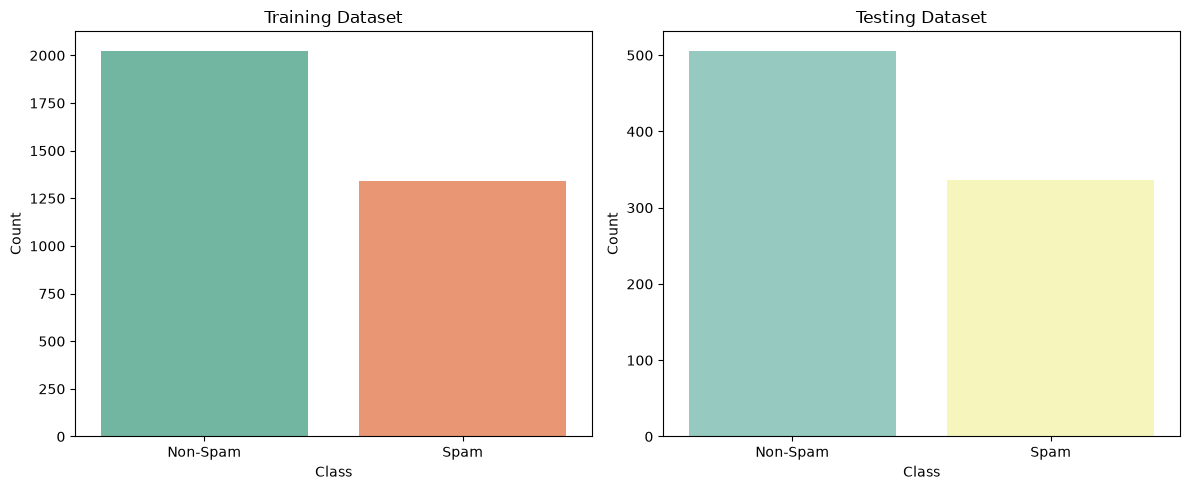

In [58]:

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x=y_train,
    ax=axes[0],
    palette="Set2"
)

axes[0].set_title("Training Dataset")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Non-Spam", "Spam"])

sns.countplot(
    x=y_test,
    ax=axes[1],
    palette="Set3"
)

axes[1].set_title("Testing Dataset")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Non-Spam", "Spam"])

plt.tight_layout()

plt.show()

### Observation

- The dataset has been successfully divided into training and testing sets.
- Approximately **80%** of the samples are used for training and **20%** for testing.
- The **stratify** parameter ensures that the proportion of spam and non-spam emails remains almost identical in both subsets.
- This helps prevent bias during model training and evaluation.

# Step 7 : Model Building

In this step, four machine learning classifiers are implemented and trained
using the training dataset.

The classifiers used are:

- Gaussian Naïve Bayes
- Multinomial Naïve Bayes
- Bernoulli Naïve Bayes
- K-Nearest Neighbour (KNN)

These models will later be evaluated using various performance metrics such as
Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.

In [63]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.neighbors import KNeighborsClassifier

## Gaussian Naïve Bayes

Gaussian Naïve Bayes assumes that every feature follows a Gaussian
(Normal) distribution.

Although the SpamBase dataset does not perfectly satisfy this assumption,
the model is implemented for comparison purposes.

In [65]:
gaussian_nb = GaussianNB()

gaussian_nb.fit(
    X_train,
    y_train
)

gaussian_prediction = gaussian_nb.predict(
    X_test
)

print("Gaussian Naive Bayes Model Trained Successfully.")

Gaussian Naive Bayes Model Trained Successfully.


## Multinomial Naïve Bayes

Multinomial Naïve Bayes is commonly used for text classification problems.
It performs well when the features represent frequencies or counts.

In [66]:

multinomial_nb = MultinomialNB()

multinomial_nb.fit(
    X_train,
    y_train
)

multinomial_prediction = multinomial_nb.predict(
    X_test
)

print("Multinomial Naive Bayes Model Trained Successfully.")

Multinomial Naive Bayes Model Trained Successfully.


## Bernoulli Naïve Bayes

Bernoulli Naïve Bayes is suitable for binary-valued features.

Although the SpamBase dataset contains continuous values, this classifier
is implemented to compare its performance with other Naïve Bayes variants.

In [68]:


bernoulli_nb = BernoulliNB()

bernoulli_nb.fit(
    X_train,
    y_train
)

bernoulli_prediction = bernoulli_nb.predict(
    X_test
)

print("Bernoulli Naive Bayes Model Trained Successfully.")

Bernoulli Naive Bayes Model Trained Successfully.


## K-Nearest Neighbour (KNN)

KNN is a distance-based supervised learning algorithm.

Initially, the model is trained using:

- Number of Neighbours (k) = 5
- Euclidean Distance

The value of k will be optimized later using GridSearchCV and
RandomizedSearchCV.

In [69]:

knn = KNeighborsClassifier(

    n_neighbors=5,

    metric="euclidean"

)

knn.fit(
    X_train,
    y_train
)

knn_prediction = knn.predict(
    X_test
)

print("KNN Model Trained Successfully.")

KNN Model Trained Successfully.


### Observation

- All four machine learning models have been successfully trained using the training dataset.
- Each model has generated predictions on the testing dataset.
- The prediction results will be evaluated in the subsequent sections using performance metrics and comparison plots.

In [71]:

models = {

    "Gaussian Naive Bayes": gaussian_nb,

    "Multinomial Naive Bayes": multinomial_nb,

    "Bernoulli Naive Bayes": bernoulli_nb,

    "K-Nearest Neighbour": knn

}

print("="*70)
print("Models Implemented")
print("="*70)

for model in models:
    print(model)

Models Implemented
Gaussian Naive Bayes
Multinomial Naive Bayes
Bernoulli Naive Bayes
K-Nearest Neighbour


In [97]:
accuracy_table = pd.DataFrame({

    "Model":[
        "Gaussian NB",
        "Multinomial NB",
        "Bernoulli NB",
        "KNN"
    ],

    "Accuracy":[

        accuracy_score(y_test, gaussian_prediction),

        accuracy_score(y_test, multinomial_prediction),

        accuracy_score(y_test, bernoulli_prediction),

        accuracy_score(y_test, knn_prediction)

    ]

})

display(accuracy_table)

,Model,Accuracy
0,Gaussian NB,0.891924
1,Multinomial NB,0.798100
2,Bernoulli NB,0.897862
3,KNN,0.896675


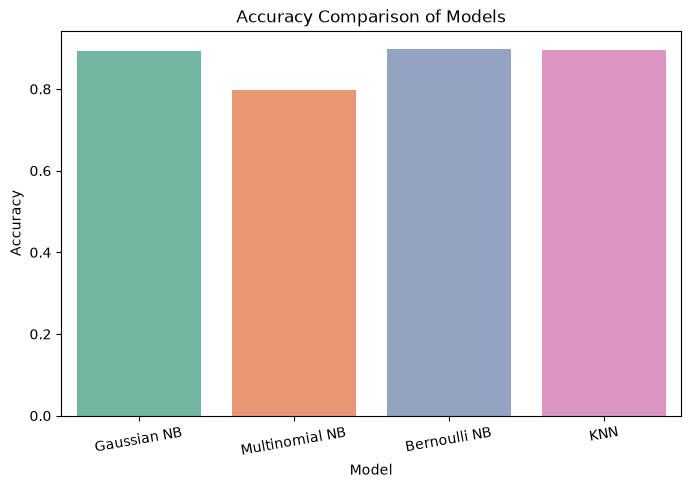

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_table,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.title("Accuracy Comparison of Models")

plt.xticks(rotation=10)

plt.show()

### Observation

- The accuracy values provide an initial comparison of all four classifiers.
- These results are obtained using the default model parameters.
- Later sections will evaluate whether hyperparameter tuning improves the performance of KNN.

# Step 8 : Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning is performed to identify the optimal configuration for
the K-Nearest Neighbour (KNN) classifier.

GridSearchCV exhaustively searches all possible combinations of the specified
hyperparameters using cross-validation.

The following hyperparameters are tuned:

- Number of Neighbours (k)
- Distance Metric
- Weight Function

The best combination obtained from GridSearchCV will be used to train the
optimized KNN classifier.

In [73]:
from sklearn.model_selection import GridSearchCV

## Parameter Grid

The following parameter combinations are evaluated.

- n_neighbors : Number of nearest neighbours
- weights : Uniform and Distance
- metric : Euclidean and Manhattan

In [74]:

param_grid = {

    "n_neighbors": list(range(1,21)),

    "weights": [

        "uniform",

        "distance"

    ],

    "metric": [

        "euclidean",

        "manhattan"

    ]

}

## Grid Search

GridSearchCV performs an exhaustive search over all parameter combinations
using 5-fold cross validation.

In [75]:

grid_search = GridSearchCV(

    estimator=KNeighborsClassifier(),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(

    X_train,

    y_train

)

print("Grid Search Completed.")

Grid Search Completed.


In [76]:

print("="*70)
print("Best Parameters")
print("="*70)

print(grid_search.best_params_)

print()

print("Best Accuracy :")

print(grid_search.best_score_)

Best Parameters
{'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}

Best Accuracy :
0.9118147627215046


In [77]:

best_knn = grid_search.best_estimator_

best_knn_prediction = best_knn.predict(

    X_test

)

print("Optimized KNN Model Created.")

Optimized KNN Model Created.


In [78]:

grid_results = pd.DataFrame(

    grid_search.cv_results_

)

grid_results = grid_results[[

    "param_n_neighbors",

    "param_metric",

    "param_weights",

    "mean_test_score",

    "rank_test_score"

]]

grid_results = grid_results.sort_values(

    by="rank_test_score"

)

display(

    grid_results.head(15)

)

,param_n_neighbors,param_metric,param_weights,mean_test_score,rank_test_score
65,13,manhattan,distance,0.911815,1
75,18,manhattan,distance,0.911518,2
67,14,manhattan,distance,0.910330,3
55,8,manhattan,distance,0.910035,4
63,12,manhattan,distance,0.909737,5
69,15,manhattan,distance,0.909439,6
61,11,manhattan,distance,0.909439,7
73,17,manhattan,distance,0.909141,8
77,19,manhattan,distance,0.908547,9
71,16,manhattan,distance,0.907955,10


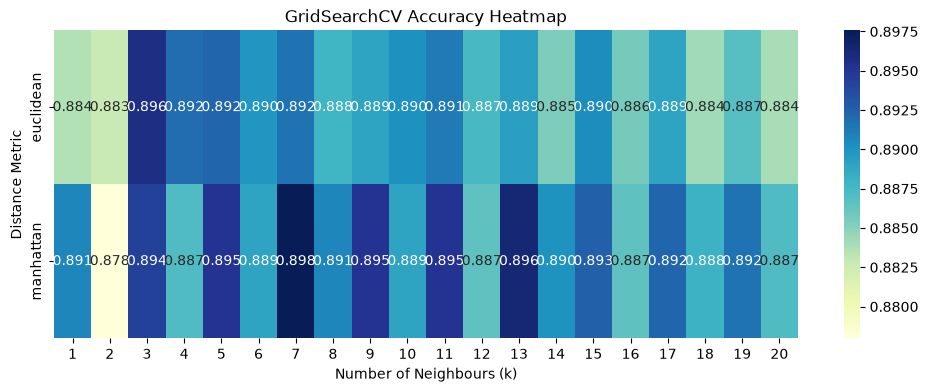

In [79]:
# ============================================================
# Grid Search Heatmap
# ============================================================

heatmap_data = grid_results[

    grid_results["param_weights"]=="uniform"

]

heatmap_data = heatmap_data.pivot(

    index="param_metric",

    columns="param_n_neighbors",

    values="mean_test_score"

)

plt.figure(figsize=(12,4))

sns.heatmap(

    heatmap_data,

    annot=True,

    fmt=".3f",

    cmap="YlGnBu"

)

plt.title("GridSearchCV Accuracy Heatmap")

plt.xlabel("Number of Neighbours (k)")

plt.ylabel("Distance Metric")

plt.show()

### Observation

- GridSearchCV evaluates all possible combinations of the specified
  hyperparameters.
- The combination with the highest cross-validation accuracy is selected
  as the optimal KNN model.
- The heatmap visually compares the performance of different values of
  **k** and distance metrics.

# Step 9 : Hyperparameter Tuning using RandomizedSearchCV

RandomizedSearchCV performs hyperparameter tuning by randomly selecting a
specified number of parameter combinations from the search space.

Compared to GridSearchCV, RandomizedSearchCV is computationally faster and
is useful when the hyperparameter search space is large.

The following hyperparameters are tuned:

- Number of Neighbours (k)
- Weight Function
- Distance Metric

In [81]:

from sklearn.model_selection import RandomizedSearchCV

In [82]:

param_dist = {

    "n_neighbors": range(1,21),

    "weights":[

        "uniform",

        "distance"

    ],

    "metric":[

        "euclidean",

        "manhattan"

    ]

}

In [83]:

random_search = RandomizedSearchCV(

    estimator=KNeighborsClassifier(),

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

random_search.fit(

    X_train,

    y_train

)

print("Randomized Search Completed.")

Randomized Search Completed.


In [84]:
# ============================================================
# Best Parameters
# ============================================================

print("="*70)
print("Best Hyperparameters")
print("="*70)

print(random_search.best_params_)

print()

print("Best Cross Validation Accuracy")

print(random_search.best_score_)

Best Hyperparameters
{'weights': 'distance', 'n_neighbors': 14, 'metric': 'manhattan'}

Best Cross Validation Accuracy
0.9103297604507917


In [85]:
# ============================================================
# Best RandomizedSearchCV Model
# ============================================================

best_random_knn = random_search.best_estimator_

best_random_prediction = best_random_knn.predict(

    X_test

)

print("Optimized KNN Model Created.")

Optimized KNN Model Created.


In [86]:
# ============================================================
# Random Search Results
# ============================================================

random_results = pd.DataFrame(

    random_search.cv_results_

)

random_results = random_results[[

    "param_n_neighbors",

    "param_metric",

    "param_weights",

    "mean_test_score",

    "rank_test_score"

]]

random_results = random_results.sort_values(

    by="rank_test_score"

)

display(

    random_results.head(15)

)

,param_n_neighbors,param_metric,param_weights,mean_test_score,rank_test_score
12,14,manhattan,distance,0.910330,1
18,8,manhattan,distance,0.910035,2
17,11,manhattan,distance,0.909439,3
16,17,manhattan,distance,0.909141,4
10,5,manhattan,distance,0.904097,5
13,18,euclidean,distance,0.901425,6
11,17,euclidean,distance,0.900832,7
3,16,euclidean,distance,0.900831,8
15,3,manhattan,distance,0.897564,9
8,3,euclidean,uniform,0.895782,10


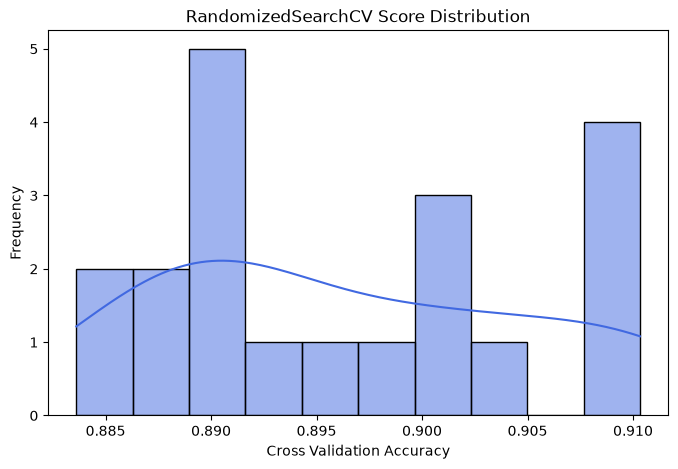

In [87]:
# ============================================================
# Randomized Search Score Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(

    random_results["mean_test_score"],

    bins=10,

    kde=True,

    color="royalblue"

)

plt.title("RandomizedSearchCV Score Distribution")

plt.xlabel("Cross Validation Accuracy")

plt.ylabel("Frequency")

plt.show()

### Observation

- RandomizedSearchCV evaluates only a subset of all possible parameter combinations.
- It significantly reduces the computation time compared to GridSearchCV.
- The best parameter combination is selected based on the highest cross-validation accuracy.
- The score distribution shows how the sampled hyperparameter combinations performed during the search.

# Step 10 : Comparison of KDTree and BallTree

KNN searches for the nearest neighbours before making a prediction.

Scikit-Learn provides different neighbour search algorithms.

In this experiment, the following search algorithms are compared:

- KDTree
- BallTree

The comparison is based on

- Training Time
- Prediction Time
- Accuracy

In [88]:

import time

from sklearn.metrics import accuracy_score

In [89]:
# ============================================================
# KDTree Implementation
# ============================================================

kd_tree = KNeighborsClassifier(

    n_neighbors=grid_search.best_params_["n_neighbors"],

    metric=grid_search.best_params_["metric"],

    weights=grid_search.best_params_["weights"],

    algorithm="kd_tree"

)

# ---------------- Training Time ----------------

start = time.perf_counter()

kd_tree.fit(

    X_train,

    y_train

)

kd_training_time = time.perf_counter() - start

# ---------------- Prediction Time ----------------

start = time.perf_counter()

kd_prediction = kd_tree.predict(

    X_test

)

kd_prediction_time = time.perf_counter() - start

kd_accuracy = accuracy_score(

    y_test,

    kd_prediction

)

In [90]:
# ============================================================
# BallTree Implementation
# ============================================================

ball_tree = KNeighborsClassifier(

    n_neighbors=grid_search.best_params_["n_neighbors"],

    metric=grid_search.best_params_["metric"],

    weights=grid_search.best_params_["weights"],

    algorithm="ball_tree"

)

# ---------------- Training Time ----------------

start = time.perf_counter()

ball_tree.fit(

    X_train,

    y_train

)

ball_training_time = time.perf_counter() - start

# ---------------- Prediction Time ----------------

start = time.perf_counter()

ball_prediction = ball_tree.predict(

    X_test

)

ball_prediction_time = time.perf_counter() - start

ball_accuracy = accuracy_score(

    y_test,

    ball_prediction

)

In [91]:
# ============================================================
# KDTree vs BallTree
# ============================================================

comparison = pd.DataFrame({

    "Algorithm":[

        "KDTree",

        "BallTree"

    ],

    "Accuracy":[

        kd_accuracy,

        ball_accuracy

    ],

    "Training Time (s)":[

        kd_training_time,

        ball_training_time

    ],

    "Prediction Time (s)":[

        kd_prediction_time,

        ball_prediction_time

    ]

})

display(comparison)

,Algorithm,Accuracy,Training Time (s),Prediction Time (s)
0,KDTree,0.920428,0.027855,0.034790
1,BallTree,0.920428,0.024505,0.028894


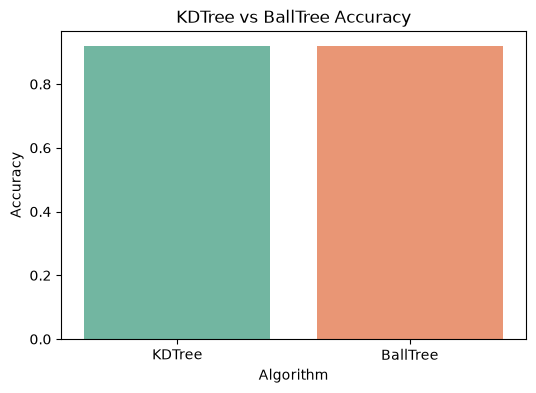

In [92]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison,

    x="Algorithm",

    y="Accuracy",

    palette="Set2"

)

plt.title("KDTree vs BallTree Accuracy")

plt.show()

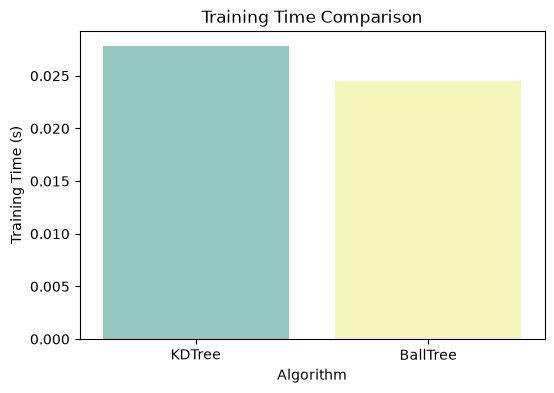

In [93]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison,

    x="Algorithm",

    y="Training Time (s)",

    palette="Set3"

)

plt.title("Training Time Comparison")

plt.show()

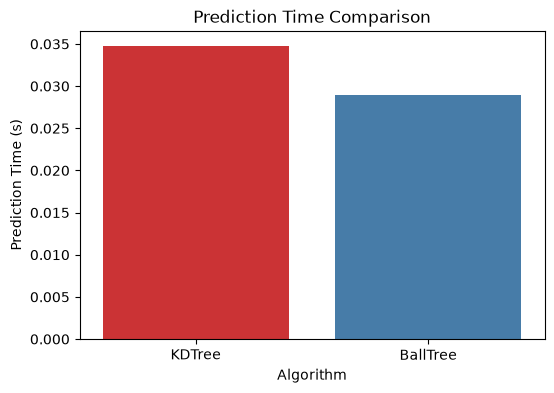

In [94]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison,

    x="Algorithm",

    y="Prediction Time (s)",

    palette="Set1"

)

plt.title("Prediction Time Comparison")

plt.show()

### Observation

- Both KDTree and BallTree produce similar classification accuracy because they use the same KNN algorithm.
- The primary difference lies in the time required for neighbour search.
- Depending on the dataset characteristics, one algorithm may provide faster prediction than the other.